Data Cleaning & Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.api.types import CategoricalDtype

In [6]:
pwd

'C:\\Users\\phyll\\Documents\\Phyllis-Take-Home-Project-'

In [11]:
cd "data"

C:\Users\phyll\Documents\Phyllis-Take-Home-Project-\data


In [12]:
data = pd.read_csv('census-bureau.data', header= None,  index_col=False)
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [13]:
# data.to_csv('census-bureau.csv', index=False) # to save version of data in csv file

In [14]:
col_names = pd.read_csv('census-bureau.columns', header=None)
# print(col_names.shape)
col_names = col_names[0].tolist()
print(len(col_names))
print(data.shape)

42
(199523, 42)


In [15]:
data.columns = col_names
data.head(5)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199523 non-null  object 
 

In [17]:
data["label"].value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [18]:
label_column = 'label'
def label_encoding(data, label_column):
    mapping = {"- 50000.": 0, "50000+.": 1}
    data[label_column] = data[label_column].map(mapping)#.astype("Int8")
    return data
data = label_encoding(data, label_column)
data.head(5)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,0


In [19]:
drop_cols = [
    "detailed industry recode",
    "detailed occupation recode",
    "weight",
    "year",
    "region of previous residence",
    "state of previous residence",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "live in this house 1 year ago",
    "migration prev res in sunbelt",
    'family members under 18',
    "country of birth father",
    "country of birth mother",
    "fill inc questionnaire for veteran's admin" #this col mostly not in universe
]
data = data.drop(columns=drop_cols)
data.head(5)

,age,class of worker,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,...,tax filer stat,detailed household and family stat,detailed household summary in household,num persons worked for employer,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,label
0,73,Not in universe,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,...,Nonfiler,Other Rel 18+ ever marr not in subfamily,Other relative of householder,0,United-States,Native- Born in the United States,0,2,0,0
1,58,Self-employed-not incorporated,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,...,Head of household,Householder,Householder,1,United-States,Native- Born in the United States,0,2,52,0
2,18,Not in universe,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,...,Nonfiler,Child 18+ never marr Not in a subfamily,Child 18 or older,0,Vietnam,Foreign born- Not a citizen of U S,0,2,0,0
3,9,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,...,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,0,United-States,Native- Born in the United States,0,0,0,0
4,10,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,...,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,0,United-States,Native- Born in the United States,0,0,0,0


In [20]:
# combine capital gains, losses, and dividends into one feat
data['net_capital_investments'] = data['capital gains'] - data['capital losses'] + data['dividends from stocks']
data = data.drop(columns=['capital gains', 'capital losses', 'dividends from stocks'])
data.head(5)

,age,class of worker,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,...,detailed household and family stat,detailed household summary in household,num persons worked for employer,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments
0,73,Not in universe,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,...,Other Rel 18+ ever marr not in subfamily,Other relative of householder,0,United-States,Native- Born in the United States,0,2,0,0,0
1,58,Self-employed-not incorporated,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,...,Householder,Householder,1,United-States,Native- Born in the United States,0,2,52,0,0
2,18,Not in universe,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,...,Child 18+ never marr Not in a subfamily,Child 18 or older,0,Vietnam,Foreign born- Not a citizen of U S,0,2,0,0,0
3,9,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,...,Child <18 never marr not in subfamily,Child under 18 never married,0,United-States,Native- Born in the United States,0,0,0,0,0
4,10,Not in universe,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,...,Child <18 never marr not in subfamily,Child under 18 never married,0,United-States,Native- Born in the United States,0,0,0,0,0


I think capital gains, losses, dividends can all me added together to get the net value of these variables for simplicity, because getting the net is useful.

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 25 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   age                                      199523 non-null  int64 
 1   class of worker                          199523 non-null  object
 2   education                                199523 non-null  object
 3   wage per hour                            199523 non-null  int64 
 4   enroll in edu inst last wk               199523 non-null  object
 5   marital stat                             199523 non-null  object
 6   major industry code                      199523 non-null  object
 7   major occupation code                    199523 non-null  object
 8   race                                     199523 non-null  object
 9   hispanic origin                          198649 non-null  object
 10  sex                                      199

C:\Users\phyll\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\phyll\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


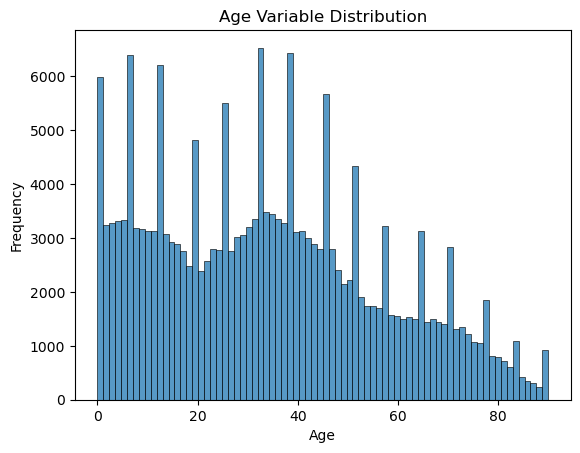

In [22]:

plt.figure()
sns.histplot(data['age'])
plt.title('Age Variable Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [23]:
age_65_plus_income = data[data['age'] > 65]['label'].value_counts()
print(age_65_plus_income)

label
0    21893
1      846
Name: count, dtype: int64


In [24]:
under_18 = data[data['age'] < 18]['label'].value_counts()
print(under_18)

label
0    55990
1        2
Name: count, dtype: int64


In [25]:
data = data[data['age'] > 18]

In [26]:
for column in data.select_dtypes(include=['object']).columns:
    print("Column:", {column})
    print(data[column].value_counts())

Column: {'class of worker'}
class of worker
Private                           68539
Not in universe                   46002
Self-employed-not incorporated     8275
Local government                   7655
State government                   4173
Self-employed-incorporated         3213
Federal government                 2903
Never worked                        147
Without pay                         140
Name: count, dtype: int64
Column: {'education'}
education
High school graduate                      47795
Some college but no degree                27387
Bachelors degree(BA AB BS)                19863
Masters degree(MA MS MEng MEd MSW MBA)     6541
7th and 8th grade                          6317
Associates degree-occup /vocational        5356
10th grade                                 4815
11th grade                                 4616
Associates degree-academic program         4363
9th grade                                  3463
5th or 6th grade                           3219
Prof schoo

In [27]:
data['class of worker'] = data['class of worker'].replace(['Local government', 'State government', 'Federal government'], 'Government')
data['class of worker'] = data['class of worker'].replace(['Self-employed-incorporated', 'Self-employed-not incorporated'], 'Self-employed')
data['class of worker'] = data['class of worker'].replace(['Never worked', 'Without pay'], 'Other')

data = pd.get_dummies(data, columns=['class of worker'], drop_first=True, dtype=int)
data.head()

,age,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,...,citizenship,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,class of worker_Private,class of worker_Self-employed
0,73,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,...,Native- Born in the United States,0,2,0,0,0,1,0,0,0
1,58,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,...,Native- Born in the United States,0,2,52,0,0,0,0,0,1
5,48,Some college but no degree,1200,Not in universe,Married-civilian spouse present,Entertainment,Professional specialty,Amer Indian Aleut or Eskimo,All other,Female,...,Native- Born in the United States,2,2,52,0,0,0,0,1,0
6,42,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,Finance insurance and real estate,Executive admin and managerial,White,All other,Male,...,Native- Born in the United States,0,2,52,0,5178,0,0,1,0
7,28,High school graduate,0,Not in universe,Never married,Construction,Handlers equip cleaners etc,White,All other,Female,...,Native- Born in the United States,0,2,30,0,0,0,0,1,0


In [28]:
major_industry_counts = data['major industry code'].value_counts()
industries_to_group = major_industry_counts[major_industry_counts < 1000].index.tolist()
data['major industry code'] = data['major industry code'].replace(industries_to_group, 'Other industry')
data = pd.get_dummies(data, columns=['major industry code'], drop_first=True, dtype=int)

major_occupation_counts = data['major occupation code'].value_counts()
occupations_to_group = major_occupation_counts[major_occupation_counts < 1000].index.tolist()
data['major occupation code'] = data['major occupation code'].replace(occupations_to_group, 'Other occupation')

data = pd.get_dummies(data, columns=['major occupation code'], drop_first=True, dtype=int)
data.head()

,age,education,wage per hour,enroll in edu inst last wk,marital stat,race,hispanic origin,sex,member of a labor union,reason for unemployment,...,major occupation code_Machine operators assmblrs & inspctrs,major occupation code_Not in universe,major occupation code_Other occupation,major occupation code_Other service,major occupation code_Precision production craft & repair,major occupation code_Professional specialty,major occupation code_Protective services,major occupation code_Sales,major occupation code_Technicians and related support,major occupation code_Transportation and material moving
0,73,High school graduate,0,Not in universe,Widowed,White,All other,Female,Not in universe,Not in universe,...,0,1,0,0,0,0,0,0,0,0
1,58,Some college but no degree,0,Not in universe,Divorced,White,All other,Male,Not in universe,Not in universe,...,0,0,0,0,1,0,0,0,0,0
5,48,Some college but no degree,1200,Not in universe,Married-civilian spouse present,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,...,0,0,0,0,0,1,0,0,0,0
6,42,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,White,All other,Male,Not in universe,Not in universe,...,0,0,0,0,0,0,0,0,0,0
7,28,High school graduate,0,Not in universe,Never married,White,All other,Female,Not in universe,Job loser - on layoff,...,0,0,0,0,0,0,0,0,0,0


In [29]:
countries_to_keep = ['United-States',
    'Mexico',
    'Puerto Rico',
    'Cuba',
    'Philippines',
    'Germany',
    'Canada',
    'El-Salvador',
    'Dominican-Republic',
    'China',
    'India']

data['country of birth self'] = data['country of birth self'].apply(lambda x: x if x in countries_to_keep else 'Other countries')
data = pd.get_dummies(data, columns=['country of birth self'], drop_first=True, dtype=int)
data.head()

,age,education,wage per hour,enroll in edu inst last wk,marital stat,race,hispanic origin,sex,member of a labor union,reason for unemployment,...,country of birth self_China,country of birth self_Cuba,country of birth self_Dominican-Republic,country of birth self_El-Salvador,country of birth self_Germany,country of birth self_India,country of birth self_Mexico,country of birth self_Other countries,country of birth self_Philippines,country of birth self_United-States
0,73,High school graduate,0,Not in universe,Widowed,White,All other,Female,Not in universe,Not in universe,...,0,0,0,0,0,0,0,0,0,1
1,58,Some college but no degree,0,Not in universe,Divorced,White,All other,Male,Not in universe,Not in universe,...,0,0,0,0,0,0,0,0,0,1
5,48,Some college but no degree,1200,Not in universe,Married-civilian spouse present,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,...,0,0,0,0,0,0,0,0,0,1
6,42,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,White,All other,Male,Not in universe,Not in universe,...,0,0,0,0,0,0,0,0,0,1
7,28,High school graduate,0,Not in universe,Never married,White,All other,Female,Not in universe,Job loser - on layoff,...,0,0,0,0,0,0,0,0,0,1


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141047 entries, 0 to 199522
Data columns (total 68 columns):
 #   Column                                                       Non-Null Count   Dtype 
---  ------                                                       --------------   ----- 
 0   age                                                          141047 non-null  int64 
 1   education                                                    141047 non-null  object
 2   wage per hour                                                141047 non-null  int64 
 3   enroll in edu inst last wk                                   141047 non-null  object
 4   marital stat                                                 141047 non-null  object
 5   race                                                         141047 non-null  object
 6   hispanic origin                                              140389 non-null  object
 7   sex                                                          141047 non-null  o

In [31]:
def citizenship_binary_encode(df):
    df['is_native'] = 0
    native_born_categories = [
        'Native- Born in the United States',
        'Native- Born in Puerto Rico or U S Outlying',
        'Native- Born abroad of American Parent(s)'
    ]
    df.loc[df['citizenship'].isin(native_born_categories), 'is_native'] = 1
    df = df.drop(columns=['citizenship'])
    return df

data = citizenship_binary_encode(data)

In [32]:
data['reason for unemployment'] = data['reason for unemployment'].replace(['Other job loser', 'Job loser - on layoff'], 'Job loser')
data = pd.get_dummies(data, columns=['reason for unemployment'], drop_first=True, dtype=int)

data = pd.get_dummies(data, columns=['member of a labor union'], drop_first=True, dtype=int)
data['full or part time employment stat'] = data['full or part time employment stat'].replace('Full-time schedules', 'Full-time')
data['full or part time employment stat'] = data['full or part time employment stat'].replace(['PT for non-econ reasons usually FT', 'PT for econ reasons usually PT', 'PT for econ reasons usually FT'], 'Part-time')
data['full or part time employment stat'] = data['full or part time employment stat'].replace(['Unemployed full-time', 'Unemployed part- time'], 'Unemployed')
data['full or part time employment stat'] = data['full or part time employment stat'].replace('Children or Armed Forces', 'Children or Armed Forces')
data = pd.get_dummies(data, columns=['full or part time employment stat'], drop_first=True, dtype=int)

data.head()

,age,education,wage per hour,enroll in edu inst last wk,marital stat,race,hispanic origin,sex,tax filer stat,detailed household and family stat,...,reason for unemployment_Job loser,reason for unemployment_New entrant,reason for unemployment_Not in universe,reason for unemployment_Re-entrant,member of a labor union_Not in universe,member of a labor union_Yes,full or part time employment stat_Full-time,full or part time employment stat_Not in labor force,full or part time employment stat_Part-time,full or part time employment stat_Unemployed
0,73,High school graduate,0,Not in universe,Widowed,White,All other,Female,Nonfiler,Other Rel 18+ ever marr not in subfamily,...,0,0,1,0,1,0,0,1,0,0
1,58,Some college but no degree,0,Not in universe,Divorced,White,All other,Male,Head of household,Householder,...,0,0,1,0,1,0,0,0,0,0
5,48,Some college but no degree,1200,Not in universe,Married-civilian spouse present,Amer Indian Aleut or Eskimo,All other,Female,Joint both under 65,Spouse of householder,...,0,0,1,0,0,0,1,0,0,0
6,42,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,White,All other,Male,Joint both under 65,Householder,...,0,0,1,0,1,0,0,0,0,0
7,28,High school graduate,0,Not in universe,Never married,White,All other,Female,Single,Secondary individual,...,1,0,0,0,1,0,0,0,0,1


In [33]:
data['enroll in edu inst last wk'] = data['enroll in edu inst last wk'].replace('College or university', 'College')
data = pd.get_dummies(data, columns=['enroll in edu inst last wk'], drop_first=True, dtype=int)
data['detailed household and family stat'] = data['detailed household and family stat'].replace(['Householder', 'Nonfamily householder'], 'Householder')
data['detailed household and family stat'] = data['detailed household and family stat'].replace(['Spouse of householder', 'Other Rel 18+ spouse of subfamily RP', 'Spouse of RP of unrelated subfamily'], 'Spouse')
data['detailed household and family stat'] = data['detailed household and family stat'].replace(['Child 18+ never marr Not in a subfamily', 'Child 18+ ever marr Not in a subfamily', 'Child 18+ ever marr RP of subfamily', 'Child 18+ never marr RP of subfamily', 'Child 18+ spouse of subfamily RP'], 'Child 18+')
data['detailed household and family stat'] = data['detailed household and family stat'].replace(['Other Rel 18+ ever marr not in subfamily', 'Other Rel 18+ never marr not in subfamily', 'Other Rel 18+ ever marr RP of subfamily', 'Other Rel 18+ never marr RP of subfamily', 'Grandchild 18+ never marr not in subfamily', 'Grandchild 18+ ever marr not in subfamily', 'Grandchild 18+ spouse of subfamily RP', 'Grandchild 18+ ever marr RP of subfamily', 'Grandchild 18+ never marr RP of subfamily'], 'Other relative')
data['detailed household and family stat'] = data['detailed household and family stat'].replace(['Secondary individual', 'RP of unrelated subfamily'], 'Nonrelative')
data['detailed household and family stat'] = data['detailed household and family stat'].replace('In group quarters', 'Group quarters')
data = pd.get_dummies(data, columns=['detailed household and family stat'], drop_first=True, dtype=int)

data['detailed household summary in household'] = data['detailed household summary in household'].replace('Householder', 'Householder')
data['detailed household summary in household'] = data['detailed household summary in household'].replace('Spouse of householder', 'Spouse')
data['detailed household summary in household'] = data['detailed household summary in household'].replace('Child 18 or older', 'Child 18+')
data['detailed household summary in household'] = data['detailed household summary in household'].replace('Other relative of householder', 'Other relative')
data['detailed household summary in household'] = data['detailed household summary in household'].replace('Nonrelative of householder', 'Nonrelative')
data['detailed household summary in household'] = data['detailed household summary in household'].replace('Group Quarters- Secondary individual', 'Group quarters')

data = pd.get_dummies(data, columns=['detailed household summary in household'], drop_first=True, dtype=int)
data.head()


,age,education,wage per hour,marital stat,race,hispanic origin,sex,tax filer stat,num persons worked for employer,own business or self employed,...,detailed household and family stat_Group quarters,detailed household and family stat_Householder,detailed household and family stat_Nonrelative,detailed household and family stat_Other relative,detailed household and family stat_Spouse,detailed household summary in household_Group quarters,detailed household summary in household_Householder,detailed household summary in household_Nonrelative,detailed household summary in household_Other relative,detailed household summary in household_Spouse
0,73,High school graduate,0,Widowed,White,All other,Female,Nonfiler,0,0,...,0,0,0,1,0,0,0,0,1,0
1,58,Some college but no degree,0,Divorced,White,All other,Male,Head of household,1,0,...,0,1,0,0,0,0,1,0,0,0
5,48,Some college but no degree,1200,Married-civilian spouse present,Amer Indian Aleut or Eskimo,All other,Female,Joint both under 65,1,2,...,0,0,0,0,1,0,0,0,0,1
6,42,Bachelors degree(BA AB BS),0,Married-civilian spouse present,White,All other,Male,Joint both under 65,6,0,...,0,1,0,0,0,0,1,0,0,0
7,28,High school graduate,0,Never married,White,All other,Female,Single,4,0,...,0,0,1,0,0,0,0,1,0,0


In [34]:
education_mapping = {
    'Less than 1st grade': 'Less than high school',
    '1st 2nd 3rd or 4th grade': 'Less than high school',
    '5th or 6th grade': 'Less than high school',
    '7th and 8th grade': 'Less than high school',
    '9th grade': 'Less than high school',
    '10th grade': 'Less than high school',
    '11th grade': 'Less than high school',
    '12th grade no diploma': 'Less than high school',
    'High school graduate': 'High school graduate',
    'Some college but no degree': 'Some college / Associate',
    'Associates degree-occup /vocational': 'Some college / Associate',
    'Associates degree-academic program': 'Some college / Associate',
    'Bachelors degree(BA AB BS)': 'Bachelor',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Master',
    'Prof school degree (MD DDS DVM LLB JD)': 'Professional degree',
    'Doctorate degree(PhD EdD)': 'Doctorate'
}

# Apply mapping
data['education'] = data['education'].map(education_mapping)


education_order = [
    'Less than high school',
    'High school graduate',
    'Some college / Associate',
    'Bachelor',
    'Master',
    'Professional degree',
    'Doctorate'
]

education_category = CategoricalDtype(categories=education_order, ordered=True)
data['education'] = data['education'].astype(education_category)

In [35]:
data['education_ordinal'] = data['education'].cat.codes
data = data.drop(columns=['education'])
data = pd.get_dummies(data, columns=['marital stat'], drop_first=True, dtype=int)
data = pd.get_dummies(data, columns=['race'], drop_first=True, dtype=int)
data = pd.get_dummies(data, columns=['sex'], drop_first=True, dtype=int)
data = pd.get_dummies(data, columns=['tax filer stat'], drop_first=True, dtype=int)
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
Index: 141047 entries, 0 to 199522
Data columns (total 96 columns):
 #   Column                                                       Non-Null Count   Dtype 
---  ------                                                       --------------   ----- 
 0   age                                                          141047 non-null  int64 
 1   wage per hour                                                141047 non-null  int64 
 2   hispanic origin                                              140389 non-null  object
 3   num persons worked for employer                              141047 non-null  int64 
 4   own business or self employed                                141047 non-null  int64 
 5   veterans benefits                                            141047 non-null  int64 
 6   weeks worked in year                                         141047 non-null  int64 
 7   label                                                        141047 non-null  i

,age,wage per hour,hispanic origin,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,...,race_Asian or Pacific Islander,race_Black,race_Other,race_White,sex_Male,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single
0,73,0,All other,0,0,2,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1,58,0,All other,1,0,2,52,0,0,0,...,0,0,0,1,1,0,0,0,0,0
5,48,1200,All other,1,2,2,52,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6,42,0,All other,6,0,2,52,0,5178,0,...,0,0,0,1,1,0,1,0,0,0
7,28,0,All other,4,0,2,30,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [36]:
hispanic_mapping = {
    'All other': 'Not_Hispanic',
    'Mexican (Mexicano)': 'Mexican',
    'Mexican-American': 'Mexican',
    'Chicano': 'Mexican',
    'Puerto Rican': 'Other_Hispanic',
    'Cuban': 'Other_Hispanic',
    'Central or South American': 'Other_Hispanic',
    'Other Spanish': 'Other_Hispanic',
    'Do not know': 'Other_Hispanic'
}
data['hispanic_group'] = data['hispanic origin'].map(hispanic_mapping)

data['hispanic_group'] = data['hispanic_group'].fillna('Not_Hispanic')

data = pd.get_dummies(data, columns=['hispanic_group'], drop_first=True, dtype=int)
data = data.drop(columns=['hispanic origin'])


In [37]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 141047 entries, 0 to 199522
Data columns (total 97 columns):
 #   Column                                                       Non-Null Count   Dtype
---  ------                                                       --------------   -----
 0   age                                                          141047 non-null  int64
 1   wage per hour                                                141047 non-null  int64
 2   num persons worked for employer                              141047 non-null  int64
 3   own business or self employed                                141047 non-null  int64
 4   veterans benefits                                            141047 non-null  int64
 5   weeks worked in year                                         141047 non-null  int64
 6   label                                                        141047 non-null  int64
 7   net_capital_investments                                      141047 non-null  int64
 8  

,age,wage per hour,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,...,race_Other,race_White,sex_Male,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic
0,73,0,0,0,2,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
1,58,0,1,0,2,52,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
5,48,1200,1,2,2,52,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
6,42,0,6,0,2,52,0,5178,0,0,...,0,1,1,0,1,0,0,0,1,0
7,28,0,4,0,2,30,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0


In [38]:
data.columns

Index(['age', 'wage per hour', 'num persons worked for employer',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'label', 'net_capital_investments',
       'class of worker_Not in universe', 'class of worker_Other',
       'class of worker_Private', 'class of worker_Self-employed',
       'major industry code_Business and repair services',
       'major industry code_Communications',
       'major industry code_Construction', 'major industry code_Education',
       'major industry code_Entertainment',
       'major industry code_Finance insurance and real estate',
       'major industry code_Hospital services',
       'major industry code_Manufacturing-durable goods',
       'major industry code_Manufacturing-nondurable goods',
       'major industry code_Medical except hospital',
       'major industry code_Not in universe or children',
       'major industry code_Other industry',
       'major industry code_Other professional services',
  

In [39]:
data.shape[1]

97

In [40]:
data.isna().any().value_counts()


False    97
Name: count, dtype: int64

In [41]:
na_counts = data.isna().sum().sort_values(ascending=False)
na_counts[na_counts > 0].head(30)


Series([], dtype: int64)

In [42]:
na_pct = (data.isna().mean() * 100).sort_values(ascending=False)
na_pct[na_pct > 0].head(30)


Series([], dtype: float64)

In [43]:
constant_cols = [c for c in data.columns if c != "label" and data[c].nunique() <= 1]
len(constant_cols), constant_cols[:20]


(0, [])

In [44]:
numeric_cols = ["age", "wage per hour", "weeks worked in year", "net_capital_investments",
                "num persons worked for employer", "own business or self employed", "veterans benefits"]

data[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,141047.0,45.158259,17.441564,19.0,31.0,42.0,57.0,90.0
wage per hour,141047.0,76.063511,322.130199,0.0,0.0,0.0,0.0,9999.0
weeks worked in year,141047.0,31.965543,23.465837,0.0,0.0,50.0,52.0,52.0
net_capital_investments,141047.0,840.192376,6330.527297,-4608.0,0.0,0.0,0.0,199998.0
num persons worked for employer,141047.0,2.651116,2.399149,0.0,0.0,2.0,5.0,6.0
own business or self employed,141047.0,0.234993,0.629296,0.0,0.0,0.0,0.0,2.0
veterans benefits,141047.0,1.985969,0.117618,1.0,2.0,2.0,2.0,2.0


In [45]:
data['wage per hour']

0            0
1            0
5         1200
6            0
7            0
          ... 
199517       0
199518       0
199519       0
199520       0
199522       0
Name: wage per hour, Length: 141047, dtype: int64

In [46]:
wage_0_count = (data['wage per hour'] == 0).sum()
wage_9999_count = (data['wage per hour'] == 9999).sum()

print(f"Occurrences of 'wage per hour' = 0: {wage_0_count}")
print(f"Occurrences of 'wage per hour' = 9999: {wage_9999_count}")

Occurrences of 'wage per hour' = 0: 130397
Occurrences of 'wage per hour' = 9999: 1


In [47]:
data['has_wage'] = (data['wage per hour'] > 0).astype(int)
data.head()

,age,wage per hour,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,...,race_White,sex_Male,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage
0,73,0,0,0,2,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,58,0,1,0,2,52,0,0,0,0,...,1,1,0,0,0,0,0,1,0,0
5,48,1200,1,2,2,52,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
6,42,0,6,0,2,52,0,5178,0,0,...,1,1,0,1,0,0,0,1,0,0
7,28,0,4,0,2,30,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0


In [48]:
data['wage_per_hour_clean'] = data['wage per hour'].replace([0, 9999], np.nan)
data['log1p_wage_clean'] = np.log1p(data['wage_per_hour_clean'])
data.drop(columns=['wage_per_hour_clean'], inplace=True)
data.head()

,age,wage per hour,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,...,sex_Male,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean
0,73,0,0,0,2,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,NaN
1,58,0,1,0,2,52,0,0,0,0,...,1,0,0,0,0,0,1,0,0,NaN
5,48,1200,1,2,2,52,0,0,0,0,...,0,0,1,0,0,0,1,0,1,7.09091
6,42,0,6,0,2,52,0,5178,0,0,...,1,0,1,0,0,0,1,0,0,NaN
7,28,0,4,0,2,30,0,0,0,0,...,0,0,0,0,0,1,1,0,0,NaN


In [49]:
data['has_investments'] = (data['net_capital_investments'] != 0).astype(int)
data.head()

,age,wage per hour,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,...,tax filer stat_Joint both 65+,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments
0,73,0,0,0,2,0,0,0,1,0,...,0,0,0,1,0,1,0,0,NaN,0
1,58,0,1,0,2,52,0,0,0,0,...,0,0,0,0,0,1,0,0,NaN,0
5,48,1200,1,2,2,52,0,0,0,0,...,0,1,0,0,0,1,0,1,7.09091,0
6,42,0,6,0,2,52,0,5178,0,0,...,0,1,0,0,0,1,0,0,NaN,1
7,28,0,4,0,2,30,0,0,0,0,...,0,0,0,0,1,1,0,0,NaN,0


In [50]:
data['signed_log_net_cap'] = np.sign(data['net_capital_investments']) * np.log1p(data['net_capital_investments'].abs())
data.head()

,age,wage per hour,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,...,tax filer stat_Joint both under 65,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap
0,73,0,0,0,2,0,0,0,1,0,...,0,0,1,0,1,0,0,NaN,0,0.000000
1,58,0,1,0,2,52,0,0,0,0,...,0,0,0,0,1,0,0,NaN,0,0.000000
5,48,1200,1,2,2,52,0,0,0,0,...,1,0,0,0,1,0,1,7.09091,0,0.000000
6,42,0,6,0,2,52,0,5178,0,0,...,1,0,0,0,1,0,0,NaN,1,8.552367
7,28,0,4,0,2,30,0,0,0,0,...,0,0,0,1,1,0,0,NaN,0,0.000000


In [51]:
print(data['veterans benefits'].value_counts())
data['veterans_benefits_binary'] = (data['veterans benefits'] == 1).astype(int)
data.drop(columns=['veterans benefits'], inplace=True)
data.head()

veterans benefits
2    139068
1      1979
Name: count, dtype: int64


,age,wage per hour,num persons worked for employer,own business or self employed,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,class of worker_Private,...,tax filer stat_Joint one under 65 & one 65+,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary
0,73,0,0,0,0,0,0,1,0,0,...,0,1,0,1,0,0,NaN,0,0.000000,0
1,58,0,1,0,52,0,0,0,0,0,...,0,0,0,1,0,0,NaN,0,0.000000,0
5,48,1200,1,2,52,0,0,0,0,1,...,0,0,0,1,0,1,7.09091,0,0.000000,0
6,42,0,6,0,52,0,5178,0,0,1,...,0,0,0,1,0,0,NaN,1,8.552367,0
7,28,0,4,0,30,0,0,0,0,1,...,0,0,1,1,0,0,NaN,0,0.000000,0


In [52]:
data['is_self_employed'] = (data['own business or self employed'] > 0).astype(int)
data.head()

,age,wage per hour,num persons worked for employer,own business or self employed,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,class of worker_Private,...,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary,is_self_employed
0,73,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,NaN,0,0.000000,0,0
1,58,0,1,0,52,0,0,0,0,0,...,0,0,1,0,0,NaN,0,0.000000,0,0
5,48,1200,1,2,52,0,0,0,0,1,...,0,0,1,0,1,7.09091,0,0.000000,0,1
6,42,0,6,0,52,0,5178,0,0,1,...,0,0,1,0,0,NaN,1,8.552367,0,0
7,28,0,4,0,30,0,0,0,0,1,...,0,1,1,0,0,NaN,0,0.000000,0,0


In [53]:
data.columns

Index(['age', 'wage per hour', 'num persons worked for employer',
       'own business or self employed', 'weeks worked in year', 'label',
       'net_capital_investments', 'class of worker_Not in universe',
       'class of worker_Other', 'class of worker_Private',
       ...
       'tax filer stat_Nonfiler', 'tax filer stat_Single',
       'hispanic_group_Not_Hispanic', 'hispanic_group_Other_Hispanic',
       'has_wage', 'log1p_wage_clean', 'has_investments', 'signed_log_net_cap',
       'veterans_benefits_binary', 'is_self_employed'],
      dtype='object', length=102)

In [54]:
drop_redundant_cols = ['own business or self employed',
    'wage per hour'
]

data = data.drop(columns=drop_redundant_cols)
data['log1p_wage_clean'] = data['log1p_wage_clean'].fillna(0)


In [55]:
data.sample(20)

,age,num persons worked for employer,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,class of worker_Private,class of worker_Self-employed,major industry code_Business and repair services,...,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary,is_self_employed
48180,52,6,52,0,0,0,0,0,0,0,...,0,0,1,0,1,7.003974,0,0.000000,0,0
38752,37,6,52,0,0,0,0,1,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
94652,35,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
50491,19,3,52,0,0,0,0,1,0,0,...,0,1,1,0,0,0.000000,0,0.000000,0,1
114298,59,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
54460,29,3,50,0,0,0,0,1,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
164536,23,4,52,0,0,0,0,1,0,0,...,0,1,1,0,1,6.685861,0,0.000000,0,0
138165,64,0,0,0,750,0,0,1,0,0,...,0,0,1,0,0,0.000000,1,6.621406,0,0
198454,22,6,52,0,0,0,0,1,0,0,...,0,1,0,0,0,0.000000,0,0.000000,0,0
44059,58,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0


In [56]:
data.to_csv('census-bureau-cleaned.csv', index=False) #saving my data to be used for feat engineering & modeling